In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image


train_dir = "../../datasets/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "../../datasets/DevanagariHandwrittenDigitDataset/Test/"
img_height, img_width = 28, 28

def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # digit_0, digit_1...
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert("L")   # grayscale
            img = img.resize((28, 28))               # resize
            img = np.array(img) / 255.0              # normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images(train_dir)
x_test, y_test = load_images(test_dir)

# Reshape for Keras
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(x_train.shape, y_train.shape)

(17000, 28, 28, 1) (17000, 10)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28,28,1)),

    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),

    Dense(10, activation='softmax')
])

model.summary()

d:\sem-6\AI-ML\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    ModelCheckpoint("best_model.h5"),
    EarlyStopping(monitor='val_loss', patience=3)
]

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2755 - loss: 1.9573

107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4821 - loss: 1.5805 - val_accuracy: 0.0000e+00 - val_loss: 8.1836
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8029 - loss: 0.6170

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8285 - loss: 0.5066 - val_accuracy: 0.0000e+00 - val_loss: 9.5234
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9035 - loss: 0.3170

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9125 - loss: 0.2927 - val_accuracy: 0.0000e+00 - val_loss: 10.3563
Epoch 4/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9367 - loss: 0.2168

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9413 - loss: 0.2047 - val_accuracy: 0.0000e+00 - val_loss: 10.7360


In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7530 - loss: 2.3005
Test Accuracy: 0.753000020980835


In [6]:
model.save("devnagari_model.h5")

loaded_model = tf.keras.models.load_model("devnagari_model.h5")

In [7]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", true_labels[0])

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Predicted: 0
Actual: 0


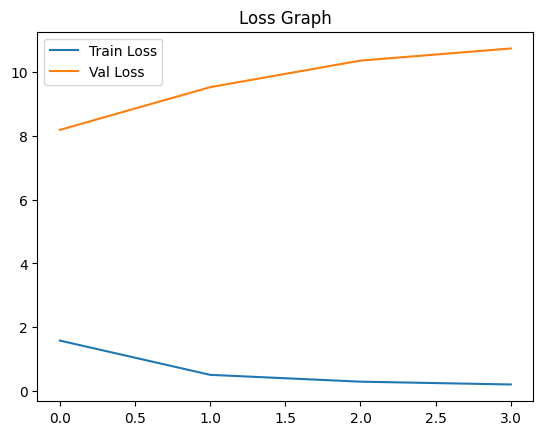

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title("Loss Graph")
plt.show()